# Indian Food Nutrition Predictor
Simple, clean notebook using MobileNetV3Large.
- Stage 1: train head (25 epochs)
- Stage 2: fine-tune last ~35 backbone layers (10 epochs)

In [10]:
# Imports
import os, pickle, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
print('Imports ready. TensorFlow', tf.__version__)

Imports ready. TensorFlow 2.15.1


In [11]:
# Configuration and reproducibility
tf.keras.backend.clear_session()
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
IMAGE_SIZE = (300, 300)
BATCH_SIZE = 32
STAGE1_EPOCHS = 25
STAGE2_EPOCHS = 10
DATASET_PATH = 'food_dataset'
MODEL_SAVE_PATH = 'best_model.keras'
CLASS_NAMES_PATH = 'class_names.pkl'
HISTORY_PATH = 'history.pkl'
NUTRITION_MAPPING_PATH = 'nutrition_mapping.pkl'
print('Config set:', IMAGE_SIZE, BATCH_SIZE)

Config set: (300, 300) 32


In [12]:
# Load dataset (80/20 split)
train_ds = tf.keras.utils.image_dataset_from_directory(DATASET_PATH, validation_split=0.2, subset='training', seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(DATASET_PATH, validation_split=0.2, subset='validation', seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
class_names = train_ds.class_names
num_classes = len(class_names)
print('Found classes:', num_classes)
# save class names
with open(CLASS_NAMES_PATH, 'wb') as f: pickle.dump(class_names, f)
# placeholder nutrition mapping
nutrition_mapping = {n: {'calories': None, 'protein': None, 'carbs': None, 'fat': None, 'sugar': None} for n in class_names}
with open(NUTRITION_MAPPING_PATH, 'wb') as f: pickle.dump(nutrition_mapping, f)
print('Saved class names and nutrition mapping (placeholder)')

Found 16660 files belonging to 106 classes.
Using 13328 files for training.
Found 16660 files belonging to 106 classes.
Using 3332 files for validation.
Found classes: 106
Saved class names and nutrition mapping (placeholder)


In [13]:
# Optimize pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
print('Pipeline optimized')

Pipeline optimized


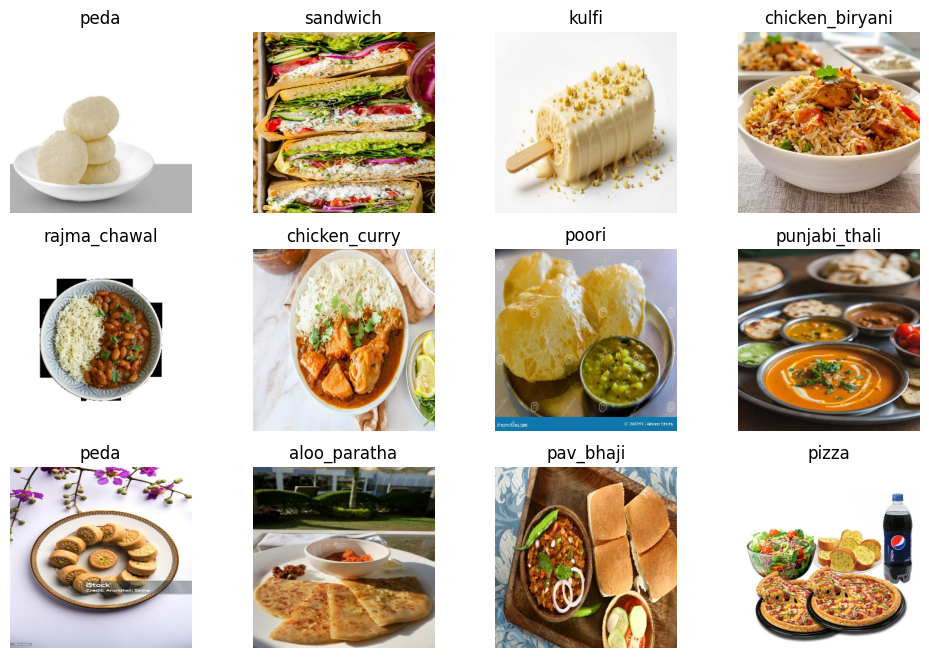

In [14]:
# Show a few examples
plt.figure(figsize=(12,8))
for images, labels in train_ds.take(1):
    for i in range(min(12, images.shape[0])):
        plt.subplot(3,4,i+1); plt.imshow(images[i].numpy().astype('uint8')); plt.title(class_names[int(labels[i])]); plt.axis('off')
plt.show()

In [15]:
# Simple augmentation (moderate)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
])
print('Augmentation ready')

Augmentation ready


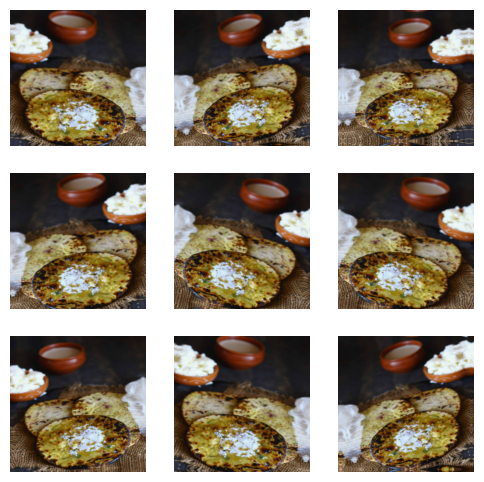

In [16]:
# Preview augmentation
plt.figure(figsize=(6,6))
for images, _ in train_ds.take(1):
    img = images[0]
    for i in range(9):
        a = data_augmentation(tf.expand_dims(img,0), training=True)
        plt.subplot(3,3,i+1); plt.imshow(a[0].numpy().astype('uint8')); plt.axis('off')
plt.show()

In [17]:
# Build model: EfficientNetB3 backbone (frozen) + small head
backbone = MobileNetV3Large(include_top=False, weights='imagenet', input_shape=(*IMAGE_SIZE,3))
backbone.trainable = False
inp = layers.Input(shape=(*IMAGE_SIZE,3))
x = data_augmentation(inp)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)
x = backbone(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
model = Model(inp, out)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 300, 300, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 300, 300, 3)       0         
                                                                 
 MobilenetV3large (Function  (None, 10, 10, 960)       2996352   
 al)                                                             
                                                                 
 global_average_pooling2d (  (None, 960)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 960)               3840      
 Normalization)                                                  
                                                             

In [19]:
# Compile (stage 1)
loss = SparseCategoricalCrossentropy()
model.compile(optimizer=Adam(learning_rate=1e-4), loss=loss, metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
ckpt = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True)
print('Compiled for stage 1')

Compiled for stage 1


In [20]:
# Stage 1: train head
h1 = model.fit(train_ds, validation_data=val_ds, epochs=STAGE1_EPOCHS, callbacks=[es, rlr, ckpt])
print('Stage 1 done; best model saved')

Epoch 1/25


417/417 [==============================] - 275s 642ms/step - loss: 4.8786 - accuracy: 0.0313 - val_loss: 4.0786 - val_accuracy: 0.1143 - lr: 1.0000e-04
Epoch 2/25
417/417 [==============================] - 267s 641ms/step - loss: 4.0819 - accuracy: 0.1149 - val_loss: 3.4294 - val_accuracy: 0.2335 - lr: 1.0000e-04
Epoch 3/25
417/417 [==============================] - 265s 636ms/step - loss: 3.5697 - accuracy: 0.1916 - val_loss: 2.9605 - val_accuracy: 0.3088 - lr: 1.0000e-04
Epoch 4/25
417/417 [==============================] - 308s 740ms/step - loss: 3.1751 - accuracy: 0.2527 - val_loss: 2.6138 - val_accuracy: 0.3727 - lr: 1.0000e-04
Epoch 5/25
417/417 [==============================] - 243s 583ms/step - loss: 2.8714 - accuracy: 0.3048 - val_loss: 2.3633 - val_accuracy: 0.4148 - lr: 1.0000e-04
Epoch 6/25
417/417 [==============================] - 238s 570ms/step - loss: 2.6292 - accuracy: 0.3473 - val_loss: 2.1726 - val_accuracy: 0.4505 - lr: 1.0000e-04
Epoch 7/25
417/417 [

In [ ]:
# Stage 2: load best model and fine-tune last ~20 layers
model = tf.keras.models.load_model(MODEL_SAVE_PATH)

# locate backbone inside model
backbone = None
for l in model.layers:
    if 'mobilenet' in l.name.lower():
        backbone = l
        break

if backbone is not None:
    backbone.trainable = True
    total = len(backbone.layers)
    start = max(0, total - 20)
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= start)
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    print('Unfroze top layers for fine-tuning')
else:
    print('Backbone not found; fine-tuning whole model (not recommended)')

# recompile with low LR
model.compile(optimizer=Adam(1e-5), loss=loss, metrics=['accuracy'])
h2 = model.fit(train_ds, validation_data=val_ds, epochs=STAGE2_EPOCHS, callbacks=[es, rlr, ckpt])
print('Fine-tuning done; best model updated if improved')

In [21]:
# Save combined history and artifacts
hist = {}
hist.update(h1.history)
hist2 = h2.history if 'h2' in globals() else {}
for k, v in hist2.items():
    hist.setdefault(k, []).extend(v)
with open(HISTORY_PATH, 'wb') as f: pickle.dump(hist, f)
print('Saved history and artifacts')

Saved history and artifacts


105/105 [==============================] - 33s 293ms/step

Classification report:

                      precision    recall  f1-score   support

           aloo_gobi       0.52      0.84      0.65        38
        aloo_paratha       0.53      0.49      0.51        37
          aloo_tikki       0.71      0.61      0.65        28
        andhra_thali       0.14      0.11      0.12        18
               appam       0.74      0.70      0.72        20
               barfi       0.57      0.56      0.57        41
       bengali_thali       0.29      0.21      0.24        24
             bhature       0.32      0.31      0.32        35
           bhel_puri       0.74      0.66      0.70        47
             biryani       0.22      0.58      0.31        24
        bread_pakora       0.62      0.67      0.64        42
              burger       0.89      0.91      0.90        35
      butter_chicken       0.48      0.59      0.53        41
         butter_naan       0.39      0.52      0

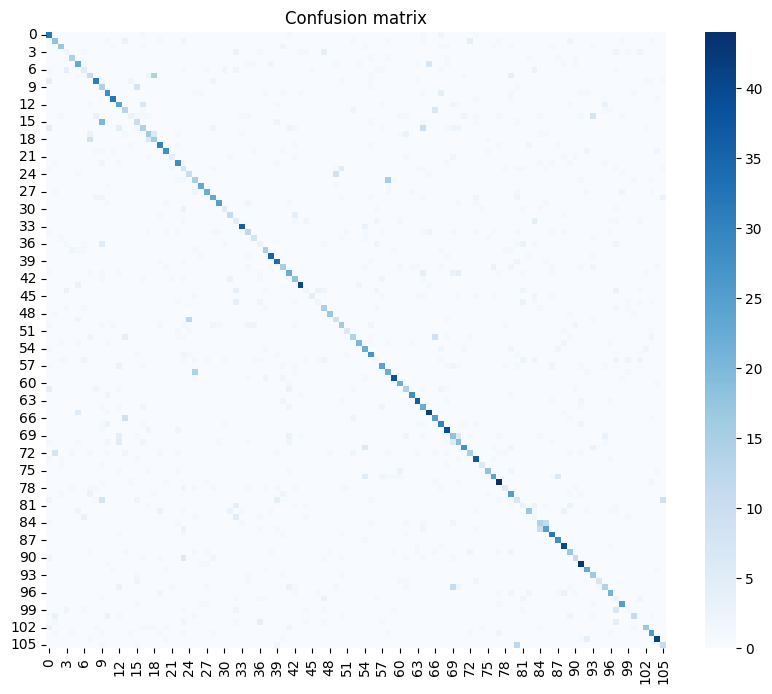

In [22]:
# Evaluation and inference helper
y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_prob = model.predict(val_ds)
y_pred = y_prob.argmax(axis=1)
print('\nClassification report:\n')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8)); sns.heatmap(cm, cmap='Blues'); plt.title('Confusion matrix'); plt.show()
def predict_food_image(path, top_k=3):
    img = tf.keras.utils.load_img(path, target_size=IMAGE_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, 0)
    preds = model.predict(arr)[0]
    idx = np.argsort(preds)[-top_k:][::-1]
    return [(class_names[i], float(preds[i])) for i in idx]
# Example: print(predict_food_image('path/to/image.jpg'))

### Notes
- Keep BatchNorm frozen during fine-tuning to avoid collapse.
- Fill `nutrition_mapping.pkl` later with real nutrition values.